<a href="https://colab.research.google.com/github/CorinnnaZ/CompChallenge/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1a
Use the ***Sellmeier formula*** to plot the refractive index of crown glass vs wavelength over the range of visible light (approximately 400nm to 800nm)

## Task 1b
Use the (provided) empirical formula to plot the refractive index of water vs frequency of visible light.

Task 1a:


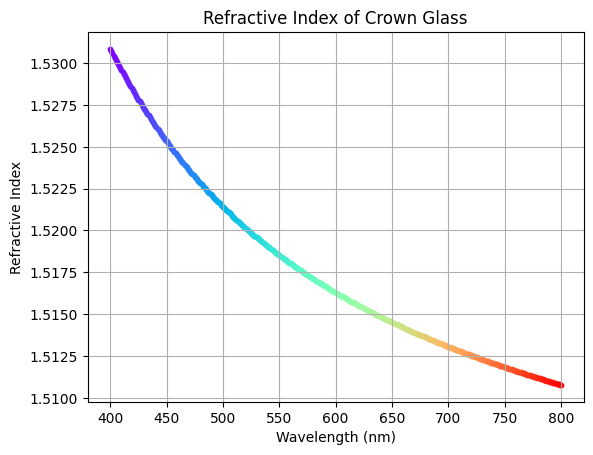

Task 1b:


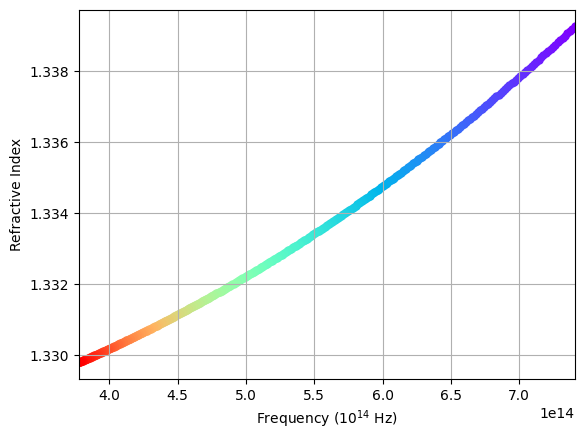

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import numpy as np

def task1a():
    # lambda
    # needs to be in range 400 to 800 nanometres
    x_nanometres = [i for i in range(400, 801)]
    x = [i/1000 for i in x_nanometres] # converted to micrometres for sellmeier's equation


    # sellmeier coefficients
    a = [1.03961212, 0.231792344, 1.01146945]
    b = [0.00600069867, 0.0200179144, 103.560653]
    n = []

    for wl in x:
        summation = []
        for j in range(3):
            s = ((a[j] * (wl**2))/((wl**2)-b[j]))
            summation.append(s)
        n_discrete = math.sqrt(1 + sum(summation))
        n.append(n_discrete)

    # make a color for each data point from the 'rainbow' colormap
    colours = cm.rainbow(np.linspace(0, 1, len(n)))

    # plot each point individually with its corresponding color
    for i in range(len(n)):
        # Use scatter for individual point coloring. 's' is the marker size.
        plt.scatter(x_nanometres[i], n[i], color=colours[i], s=10)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Refractive Index")
    plt.title('Refractive Index of Crown Glass')
    plt.grid()
    plt.show()

def task1b():
    """defining variables"""
    c = 3*(10**8) # ms^-1
    wavelength_nanometres = [i for i in range(405, 795)] # how can I make this truly continuous?
    true_wavelength_list = [(i/(10**9)) for i in wavelength_nanometres] # now in metres
    frequency_list = [(c/wl) for wl in true_wavelength_list] # in Hz

    n = []
    for frequency in frequency_list:
        embed_1 = math.sqrt(1/(1.731 - 0.261 *((frequency/(10**15))**2)))
        n_discrete = math.sqrt(embed_1 + 1)
        n.append(n_discrete)
    colours = cm.rainbow(np.linspace(0,1,len(n)))
    plt.grid()
    for i in range(len(n)):
        plt.scatter(frequency_list[i], n[i], color = colours[i], linewidth = .005)
    plt.xlim(min(frequency_list), max(frequency_list))
    plt.xlabel(r"Frequency ($10^{14}$ Hz)")
    plt.ylabel("Refractive Index")

    plt.show()

print("Task 1a:")
task1a()
print("Task 1b:")
task1b()
